# 🚜 Bluebook Bulldozer Price Prediction

## Project Overview
End-to-end regression project to predict auction sale prices of heavy equipment (bulldozers) using historical sales data from Kaggle's Blue Book for Bulldozers competition.

- **Dataset:** 412,698 rows × 53 columns
- **Target Variable:** SalePrice (auction price in USD)
- **Model:** Random Forest Regressor
- **Metric:** RMSLE (Root Mean Squared Log Error)

---

## 📦 Libraries Used

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#scikit learn

In [22]:
df = pd.read_csv(r'data/bluebook-for-bulldozers/TrainAndValid.csv',low_memory=False)

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   str    
 9   saledate                  412698 non-null  str    
 10  fiModelDesc               412698 non-null  str    
 11  fiBaseModel               412698 non-null  str    
 12  fiSecondaryDesc           271971 non-null  str    
 13  fiModelSeries             58667 non-null   str    
 14 

In [24]:
df['SalePrice'].describe()

count    412698.000000
mean      31215.181414
std       23141.743695
min        4750.000000
25%       14500.000000
50%       24000.000000
75%       40000.000000
max      142000.000000
Name: SalePrice, dtype: float64

In [25]:
df['saledate'].min(),df['saledate'].max()

('1/1/2012 0:00', '9/9/2011 0:00')

In [26]:
df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,11/16/2006 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,3/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,5/19/2011 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,7/23/2009 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
df.shape

(412698, 53)

In [28]:
df.dtypes.value_counts()

str        45
int64       5
float64     3
Name: count, dtype: int64

In [29]:
(df.isna().sum().sort_values(ascending = False).head(40))

Pushblock                   386715
Tip_Control                 386715
Enclosure_Type              386715
Engine_Horsepower           386715
Blade_Extension             386715
Blade_Width                 386715
Scarifier                   386704
Grouser_Tracks              367823
Hydraulics_Flow             367823
Coupler_System              367724
fiModelSeries               354031
Steering_Controls           341176
Differential_Type           341134
UsageBand                   339028
fiModelDescriptor           337882
Backhoe_Mounting            331986
Stick                       331602
Pad_Type                    331602
Turbocharged                331602
Blade_Type                  330823
Travel_Controls             330821
Tire_Size                   315060
Grouser_Type                310505
Track_Type                  310505
Stick_Length                310437
Pattern_Changer             310437
Thumb                       310366
Undercarriage_Pad_Width     309782
Ripper              

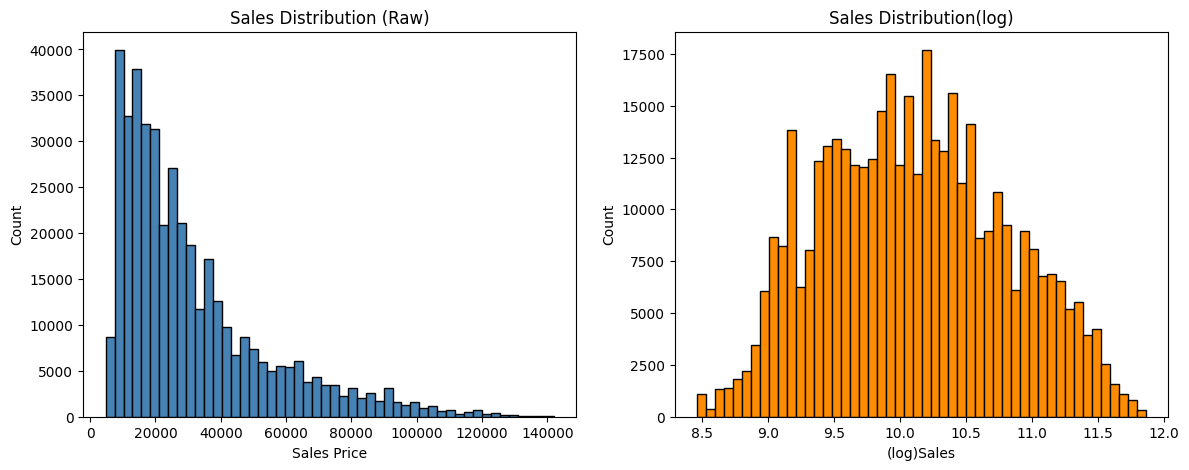

In [30]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(14,5))

ax[0].hist(df['SalePrice'],bins=50,color = 'steelblue',edgecolor='black')
ax[0].set_title('Sales Distribution (Raw)')
ax[0].set(xlabel='Sales Price',ylabel='Count')

ax[1].hist(np.log(df['SalePrice']),bins=50,color='darkorange',edgecolor='black')
ax[1].set(title='Sales Distribution(log)',xlabel='(log)Sales',ylabel = 'Count')
plt.show()


###  SalePrice Distribution
Comparing Raw vs Log-transformed SalePrice:
- **Raw:** Heavy right skew, long tail
- **Log:** Near bell curve  — better for ML models

In [31]:
df['Sale_price_log'] = np.log(df['SalePrice'])

In [32]:
df[['SalePrice','Sale_price_log']].head()

,SalePrice,Sale_price_log
0,66000.0,11.097410
1,57000.0,10.950807
2,10000.0,9.210340
3,38500.0,10.558414
4,11000.0,9.305651


## 🛠️ Phase 2: Feature Engineering

### 2.1 Date Feature Extraction
The `saledate` column contains full datetime info.
We extract year, month, day etc. so the model can learn time-based patterns.

In [33]:
df['saledate'] = pd.to_datetime(df['saledate'])
df['SaleYear'] = df['saledate'].dt.year
df['SaleMonth'] = df['saledate'].dt.month
df['SaleDay'] = df['saledate'].dt.day
df['SaleDayofWeek'] = df['saledate'].dt.dayofweek
df['SaleDayofYear'] = df['saledate'].dt.dayofyear

df.drop('saledate',axis=1,inplace=True)

In [34]:
df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,Sale_price_log,SaleYear,SaleMonth,SaleDay,SaleDayofWeek,SaleDayofYear
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,521D,...,NaN,NaN,Standard,Conventional,11.097410,2006,11,16,3,320
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,950FII,...,NaN,NaN,Standard,Conventional,10.950807,2004,3,26,4,86
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,226,...,NaN,NaN,NaN,NaN,9.210340,2004,2,26,3,57
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,PC120-6E,...,NaN,NaN,NaN,NaN,10.558414,2011,5,19,3,139
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,S175,...,NaN,NaN,NaN,NaN,9.305651,2009,7,23,3,204


In [35]:
df.shape

(412698, 58)

### 2.2 Handling String Columns & Missing Values
- Convert all string (object) columns to pandas `category` dtype
- Fill missing numeric values with median
- Use `.cat.codes` to convert categories to numbers (-1 for missing)

In [36]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include='category').columns:
    df[col] = df[col].cat.codes

C:\Users\manoj\AppData\Local\Temp\ipykernel_24416\3182836084.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [37]:
df.dtypes.value_counts()

int8       40
int64       5
int32       5
float64     4
int16       4
Name: count, dtype: int64

In [39]:
df.isna().sum().sum()

np.int64(0)

### 2.3 Sale Price Trend Over Years

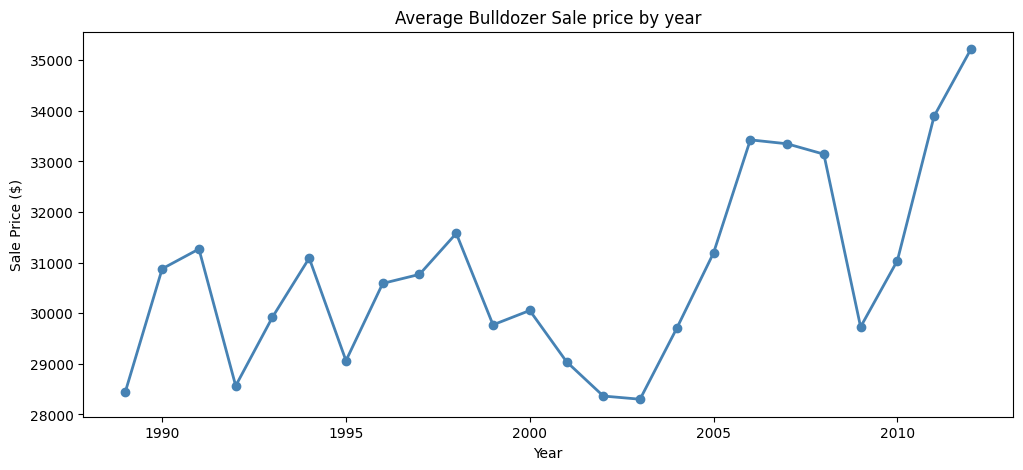

In [43]:
fig,ax = plt.subplots(figsize=(12,5))
df.groupby('SaleYear')['SalePrice'].mean().plot(
    ax=ax,
    color='steelblue',
    marker='o',
    linewidth=2
)
ax.set(title='Average Bulldozer Sale price by year',xlabel='Year',ylabel='Sale Price ($)')
plt.show()


## 🤖 Phase 3: Model Building

### 3.1 Train-Validation Split
We split by **year** (not random!) because this is time-series data.
Train: all sales before 2012 | Validation: 2012 sales

In [46]:
df_train = df[df["SaleYear"] < 2012]
df_val = df[df["SaleYear"] == 2012]

X_train = df_train.drop(columns=["SalePrice", "Sale_price_log"])
y_train = df_train["Sale_price_log"]

X_val = df_val.drop(columns=["SalePrice", "Sale_price_log"])
y_val = df_val["Sale_price_log"]

print(f"Train size: {X_train.shape}")
print(f"Validation size: {X_val.shape}")

Train size: (401125, 56)
Validation size: (11573, 56)


### 3.2 Training Random Forest Model
Random Forest = many decision trees working together like a team!
We start with a small quick model first to test everything works.

In [47]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=10,
    max_samples=10000,
    n_jobs=-1,
    random_state=42)
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [48]:
model.score(X_train,y_train)

0.8557529178285225

In [49]:
model.score(X_val,y_val)

0.8256584358795922

### 3.3 Evaluation Metric - RMSLE
RMSLE = Root Mean Squared Log Error
Lower is better! Kaggle's official metric for this competition.

In [52]:
from sklearn.metrics import mean_squared_log_error
def rmsle(y_true,y_pred):
    return np.sqrt(mean_squared_log_error(np.exp(y_true),np.exp(y_pred)))

train_preds = model.predict(X_train)
val_preds = model.predict(X_val)
print(rmsle(y_train,train_preds))
print(rmsle(y_val,val_preds))

0.2634227828123099
0.3066397372654148


### 3.4 Full Random Forest Model
Training with 100 trees on complete dataset for best performance.

In [55]:
model_v2 = RandomForestRegressor(
    n_estimators=100,
    max_features=0.5,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

model_v2.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [56]:
train_preds = model_v2.predict(X_train)
val_preds = model_v2.predict(X_val)

In [57]:
model_v2.score(X_train,y_train)

0.9883502389135765

In [58]:
model_v2.score(X_val,y_val)

0.8947521345773626

In [60]:
print(rmsle(y_train,train_preds))
print(rmsle(y_val,val_preds))

0.07486111803889436
0.23825030789946777


## 📈 Phase 4: Model Evaluation & Visualization

### 4.1 Feature Importance
Which features does the model rely on most to predict price?

In [70]:
feature_importance = pd.Series(model_v2.feature_importances_,
                               index=X_train.columns,
                              ).sort_values(ascending=False)[:15]

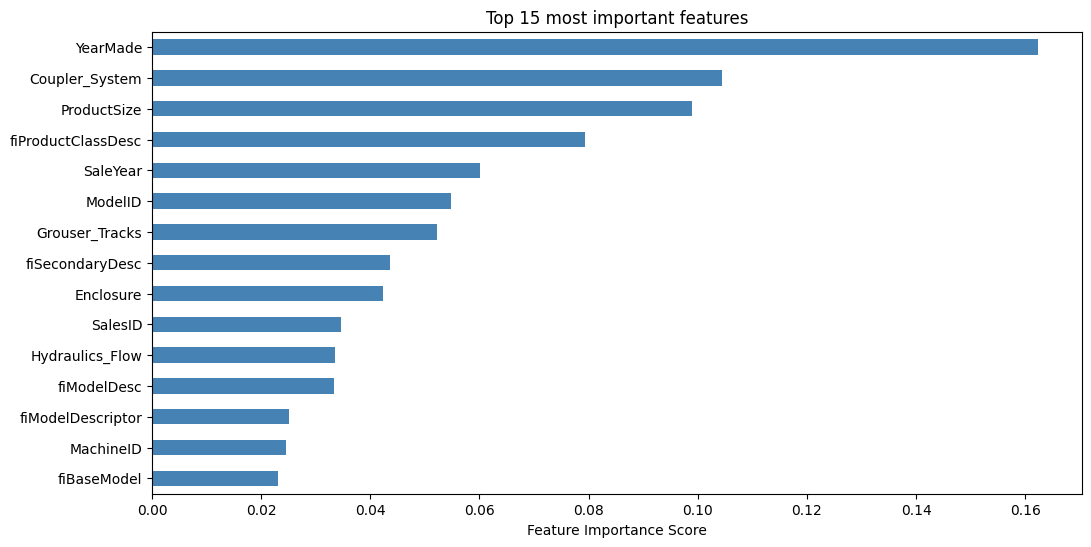

In [75]:
fig,ax = plt.subplots(figsize=(12,6))
feature_importance.plot(kind='barh',ax=ax,color='steelblue')
ax.set(title='Top 15 most important features',xlabel='Feature Importance Score')
ax.invert_yaxis()
plt.show()

## 5.Import the model using Joblib 

In [77]:
from joblib import dump
dump(model_v2,'bulldozer predict model.joblib')

['bulldozer predict model.joblib']

### Expirementation with XGBOOST ( for my personal testing)

In [92]:
from xgboost import XGBRegressor

xg_model = XGBRegressor(
    n_estimators = 1000,
    learning_rate = 0.03,
    max_depth=8,
    subsample = 0.8,
    random_state = 42,
    tree_method = 'hist'
)
    

In [93]:
xg_model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [94]:
train_preds_xg = xg_model.predict(X_train)
val_preds_xg = xg_model.predict(X_val)

In [95]:
xg_model.score(X_train,y_train)

0.925936076176119

In [96]:
xg_model.score(X_val,y_val)

0.8963300984312115

In [97]:
print(rmsle(y_train,train_preds_xg))
print(rmsle(y_val,val_preds_xg))

0.18875645593121657
0.23645749738327368


In [100]:
xg_feature_imp = pd.Series(xg_model.feature_importances_,
                           index = X_train.columns
                          ).sort_values(ascending=False)[:15]

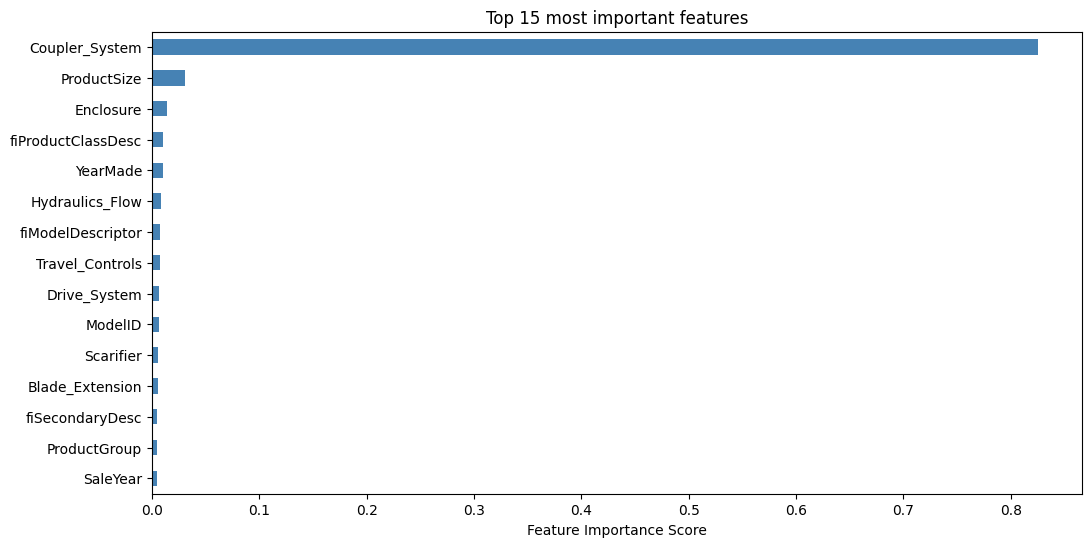

In [104]:
fig,ax = plt.subplots(figsize=(12,6))
xg_feature_imp.plot(kind='barh',
                    ax=ax,
                    color='steelblue')
ax.set(title='Top 15 most important features',xlabel='Feature Importance Score')
ax.invert_yaxis()
plt.show()